# Mutual Fund Capstone – Exploratory Data Analysis (EDA)

## Day 3: Exploratory Data Analysis

This notebook explores the cleaned mutual fund datasets through visual analysis of NAV trends, AUM growth, SIP inflows, investor demographics, geographic distribution, fund correlations, and sector allocation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'nav_history.csv' in files:
        print("Found folder:", root)
        print("Files:", files)

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'https:  open (1).sp.txt', 'https:  open.sp.txt', 'AI Powered Excel Masterclass Practice file.rar', 'AI Powered Excel Masterclass Practice file (2).rar', 'personal_Expense_Tracker.xlsx', 'personal_Expense_Tracker_Project.xlsx', 'VibeWalk_Brand_Presentation.pdf', 'Sales Dashboard_Work Sample.xlsm', 'Deloitte Certificate of completion.pdf', 'Ridhi M. Jain_Tata Data Visualisation Certificate.pdf', 'Be10x Excel with AI Workshop completion Certificate.pdf', 'BCG X Introduction to Data for Decision Makers.pdf', 'Goldman Sachs Operations .pdf', 'Ridhi M. Jain Internship Submission', 'Bluestock ', 'Excel with AI  completion Certificate.pdf', 'Ridhi M. Jain Resume.pdf']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Bluestock '))

['week 1 core data analytics foundation', 'capstone']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Bluestock /capstone'))

['raw', 'cleaned', 'notebook']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Bluestock /capstone/cleaned'))

['fund_master_cleaned.csv', 'fund_holdings_cleaned.csv', 'monthly_SIP_inflows_cleaned.csv', 'industry_folio_count_cleaned.csv', 'scheme_performance_cleaned.csv', 'Category_inflow_cleaned.csv', 'aum_cleaned.csv', 'nav_history_cleaned.csv', 'investor_transactions_cleaned.csv', 'Benchmark indices cleaned.csv']


In [ ]:
import pandas as pd
import os

# Define the exact folder path
cleaned_path = "/content/drive/MyDrive/Bluestock /capstone/cleaned"

# Check that the folder exists
print("Folder exists:", os.path.exists(cleaned_path))

# Show files inside the folder
print("\nFiles found:")
print(os.listdir(cleaned_path))

# Load datasets
fund_master = pd.read_csv(os.path.join(cleaned_path, "fund_master_cleaned.csv"))
fund_holdings = pd.read_csv(os.path.join(cleaned_path, "fund_holdings_cleaned.csv"))
sip_inflows = pd.read_csv(os.path.join(cleaned_path, "monthly_SIP_inflows_cleaned.csv"))
folio_count = pd.read_csv(os.path.join(cleaned_path, "industry_folio_count_cleaned.csv"))
scheme_performance = pd.read_csv(os.path.join(cleaned_path, "scheme_performance_cleaned.csv"))
category_inflow = pd.read_csv(os.path.join(cleaned_path, "Category_inflow_cleaned.csv"))
aum = pd.read_csv(os.path.join(cleaned_path, "aum_cleaned.csv"))
nav_history = pd.read_csv(os.path.join(cleaned_path, "nav_history_cleaned.csv"))
transactions = pd.read_csv(os.path.join(cleaned_path, "investor_transactions_cleaned.csv"))
benchmark_indices = pd.read_csv(
    os.path.join(cleaned_path, "Benchmark indices cleaned.csv")
)

print("\n✅ All 10 cleaned datasets loaded successfully!")

Folder exists: True

Files found:
['fund_master_cleaned.csv', 'fund_holdings_cleaned.csv', 'monthly_SIP_inflows_cleaned.csv', 'industry_folio_count_cleaned.csv', 'scheme_performance_cleaned.csv', 'Category_inflow_cleaned.csv', 'aum_cleaned.csv', 'nav_history_cleaned.csv', 'investor_transactions_cleaned.csv', 'Benchmark indices cleaned.csv']

✅ All 10 cleaned datasets loaded successfully!


#NAV Trend Analysis

In [ ]:
print(nav_history.columns)
print("\nShape:", nav_history.shape)
nav_history.head()

Index(['amfi_code', 'date', 'nav'], dtype='object')

Shape: (45962, 3)


,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840


In [ ]:
# Convert date to datetime
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Sort the data
nav_history = nav_history.sort_values(['amfi_code', 'date'])

# Check date range and number of schemes
print("Number of schemes:", nav_history['amfi_code'].nunique())
print("Date range:", nav_history['date'].min(), "to", nav_history['date'].max())

Number of schemes: 40
Date range: 2022-01-02 00:00:00 to 2026-12-05 00:00:00


In [ ]:
import plotly.express as px

fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trends Across Mutual Fund Schemes (2022–2026)',
    labels={
        'date': 'Date',
        'nav': 'NAV',
        'amfi_code': 'AMFI Code'
    }
)

fig.update_layout(
    height=650,
    hovermode='x unified'
)

fig.show()

<!doctype html>

In [ ]:
fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trends Across Mutual Fund Schemes (2022–2026)',
    labels={
        'date': 'Date',
        'nav': 'NAV',
        'amfi_code': 'AMFI Code'
    }
)

# Highlight 2023 bull run
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.08,
    line_width=0,
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

# Highlight 2024 market correction
fig.add_vrect(
    x0='2024-07-01',
    x1='2024-12-31',
    fillcolor='orange',
    opacity=0.08,
    line_width=0,
    annotation_text='2024 Market Correction',
    annotation_position='top left'
)

fig.update_layout(
    height=650,
    hovermode='x unified'
)



fig.show()


<!doctype html>

#AUM Growth Analysis

In [ ]:
print(aum.columns)
print("\nShape:", aum.shape)
aum.head()

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Shape: (90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
# Convert date to datetime
aum['date'] = pd.to_datetime(aum['date'])

# Extract year
aum['year'] = aum['date'].dt.year

# Filter required years
aum_yearly = aum[aum['year'].between(2022, 2025)]

# Check the available years and fund houses
print("Years:", sorted(aum_yearly['year'].unique()))
print("Fund Houses:", aum_yearly['fund_house'].unique())

Years: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Fund Houses: ['SBI Mutual Fund' 'ICICI Prudential MF' 'HDFC Mutual Fund'
 'Nippon India MF' 'Kotak Mahindra MF' 'Aditya Birla Sun Life MF'
 'Axis Mutual Fund' 'UTI Mutual Fund' 'Mirae Asset MF' 'DSP Mutual Fund']


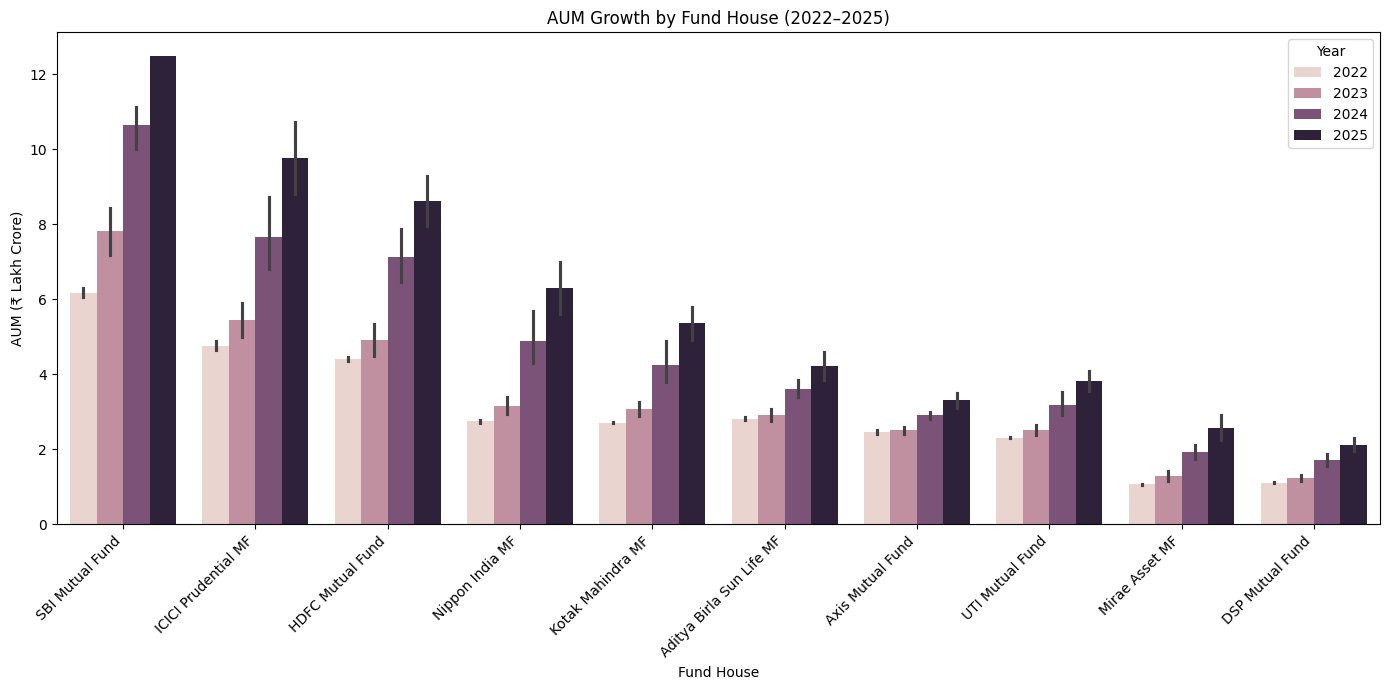

In [ ]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year'
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

plt.tight_layout()
plt.show()

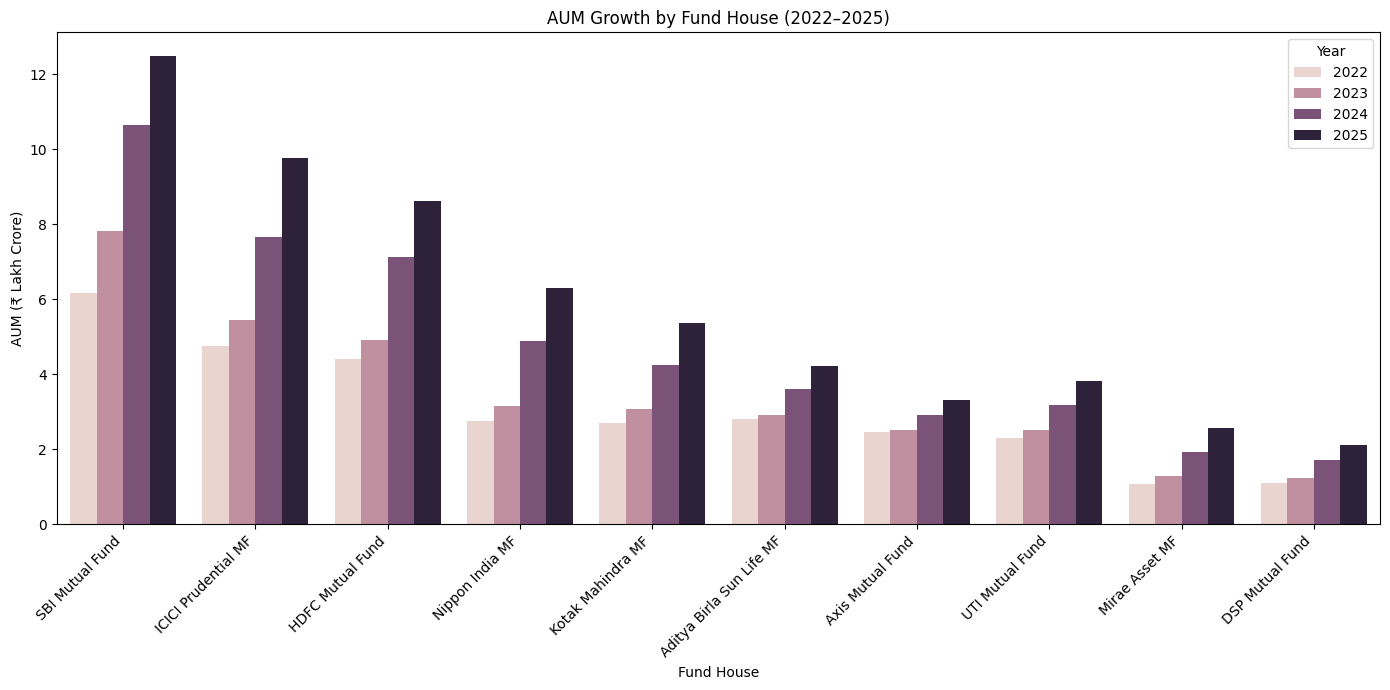

In [ ]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    errorbar=None
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

plt.tight_layout()
plt.show()

In [ ]:
# Get SBI Mutual Fund's 2025 AUM value
sbi_2025 = aum_yearly[
    (aum_yearly['fund_house'] == 'SBI Mutual Fund') &
    (aum_yearly['year'] == 2025)
]['aum_lakh_crore'].iloc[0]

print(f"SBI Mutual Fund AUM in 2025: ₹{sbi_2025:.2f} Lakh Crore")

SBI Mutual Fund AUM in 2025: ₹12.50 Lakh Crore


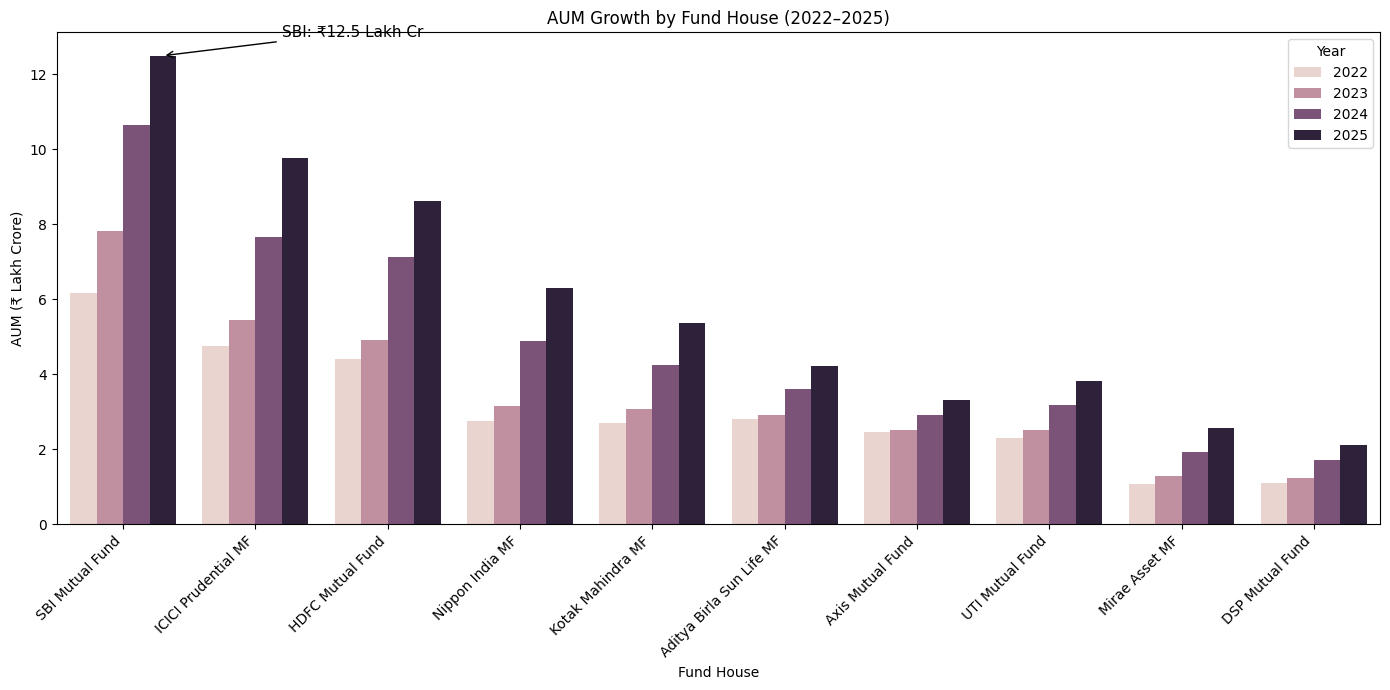

In [ ]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    errorbar=None
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

# Highlight SBI Mutual Fund's 2025 dominance
plt.annotate(
    'SBI: ₹12.5 Lakh Cr',
    xy=(0.3, 12.5),
    xytext=(1.2, 13),
    arrowprops=dict(arrowstyle='->'),
    fontsize=11
)

plt.tight_layout()
plt.show()

#SIP Inflow Trend Analysis

In [ ]:
print(sip_inflows.columns)
print("\nShape:", sip_inflows.shape)
sip_inflows.head()

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

Shape: (48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [ ]:
# Convert month to datetime
sip_inflows['month'] = pd.to_datetime(sip_inflows['month'])

# Create SIP inflow time-series chart
fig = px.line(
    sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={
        'month': 'Month',
        'sip_inflow_crore': 'SIP Inflow (₹ Crore)'
    },
    markers=True
)

fig.update_layout(
    height=550,
    hovermode='x unified'
)

fig.show()

<!doctype html>

In [ ]:
# Find the month with the highest SIP inflow
sip_peak = sip_inflows.loc[sip_inflows['sip_inflow_crore'].idxmax()]

print("Highest SIP Inflow:")
print("Month:", sip_peak['month'].strftime('%B %Y'))
print("SIP Inflow: ₹{:,.0f} Crore".format(sip_peak['sip_inflow_crore']))

Highest SIP Inflow:
Month: December 2025
SIP Inflow: ₹31,002 Crore


In [ ]:
fig = px.line(
    sip_inflows,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={
        'month': 'Month',
        'sip_inflow_crore': 'SIP Inflow (₹ Crore)'
    },
    markers=True
)

# Highlight the all-time high
fig.add_annotation(
    x=sip_peak['month'],
    y=sip_peak['sip_inflow_crore'],
    text='All-Time High: ₹31,002 Cr<br>December 2025',
    showarrow=True,
    arrowhead=2,
    ax=-100,
    ay=-60
)

fig.update_layout(
    height=550,
    hovermode='x unified'
)

fig.show()

<!doctype html>

# Category Inflow Analysis

In [ ]:
print(category_inflow.columns)
print("\nShape:", category_inflow.shape)
category_inflow.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

Shape: (144, 3)


,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [ ]:
# Convert month to datetime
category_inflow['month'] = pd.to_datetime(category_inflow['month'])

# Create a month-category pivot table
heatmap_data = category_inflow.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

print("Categories:", heatmap_data.shape[0])
print("Months:", heatmap_data.shape[1])

heatmap_data.head()

Categories: 12
Months: 12


month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


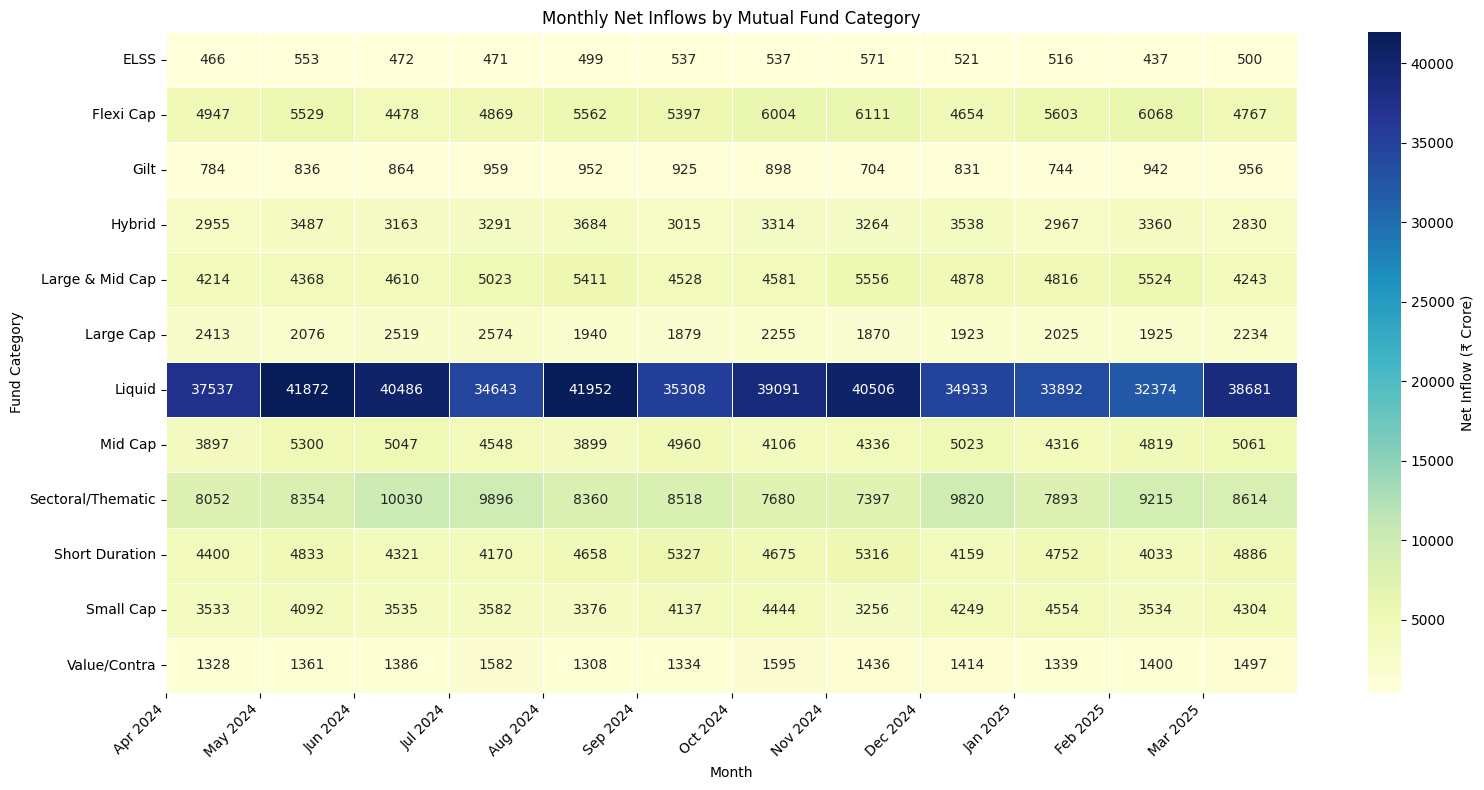

In [ ]:
plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)

plt.title('Monthly Net Inflows by Mutual Fund Category')
plt.xlabel('Month')
plt.ylabel('Fund Category')

# Format month labels
plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=[date.strftime('%b %Y') for date in heatmap_data.columns],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

#Investor Demographics

In [ ]:
print(transactions.columns)
print("\nShape:", transactions.shape)
transactions.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Shape: (32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
age_group_counts = transactions['age_group'].value_counts()

fig = px.pie(
    values=age_group_counts.values,
    names=age_group_counts.index,
    title='Investor Distribution by Age Group',
    hole=0.3
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

<!doctype html>

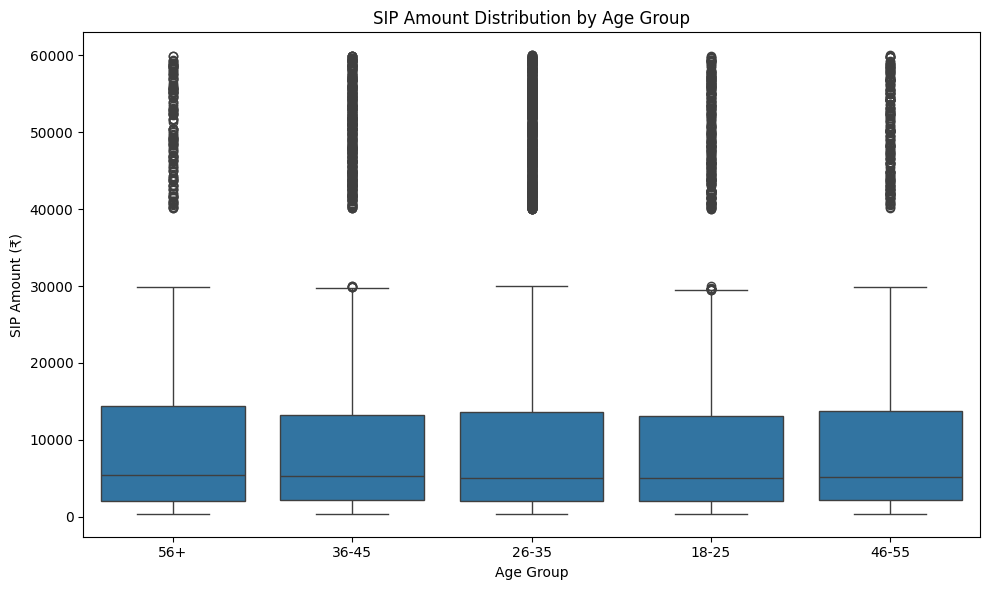

In [ ]:
# Filter only SIP transactions
sip_transactions = transactions[
    transactions['transaction_type'] == 'SIP'
]

# Create box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sip_transactions,
    x='age_group',
    y='amount_inr'
)

plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (₹)')

plt.tight_layout()
plt.show()

In [ ]:
gender_counts = transactions['gender'].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title='Investor Gender Distribution',
    hole=0.3
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

<!doctype html>

#Geographic Distribution Analysis

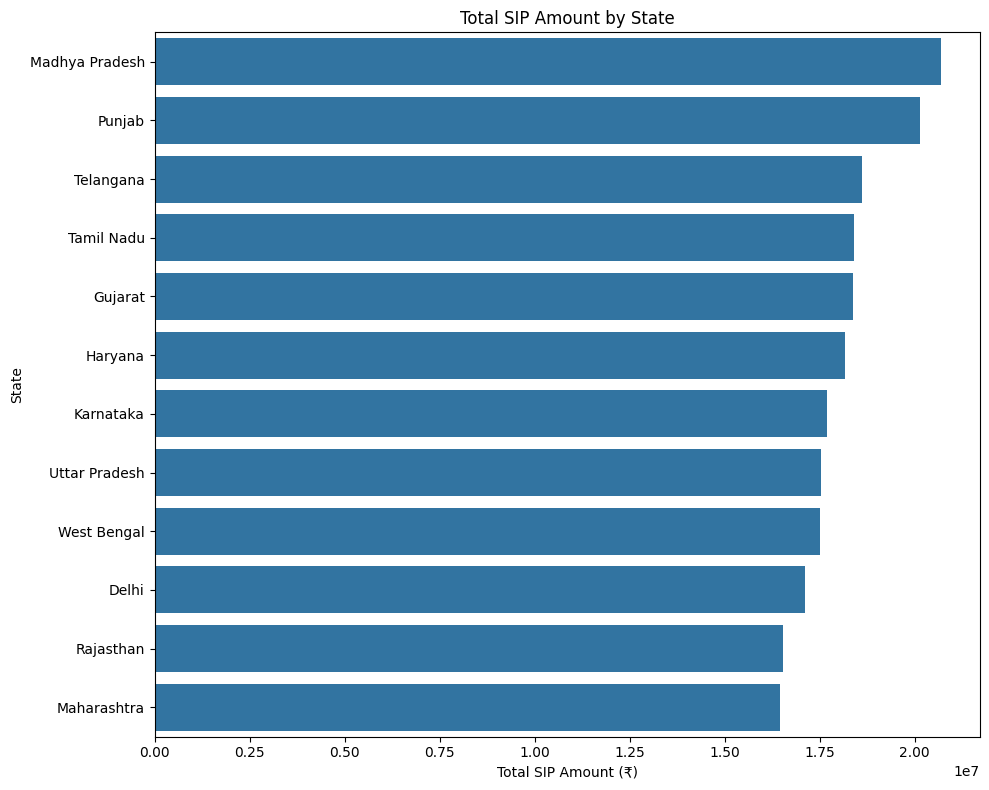

In [ ]:
# Filter SIP transactions
sip_transactions = transactions[
    transactions['transaction_type'] == 'SIP'
]

# Aggregate SIP amount by state
state_sip = (
    sip_transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=state_sip,
    x='amount_inr',
    y='state'
)

plt.title('Total SIP Amount by State')
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [ ]:
city_tier_counts = transactions['city_tier'].value_counts()

fig = px.pie(
    values=city_tier_counts.values,
    names=city_tier_counts.index,
    title='Investor Distribution by City Tier: T30 vs B30',
    hole=0.3
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.show()

<!doctype html>

# Folio Count Growth Analysis

In [ ]:
print(folio_count.columns)
print("\nShape:", folio_count.shape)
folio_count.head()

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

Shape: (21, 6)


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
# Convert month to datetime
folio_count['month'] = pd.to_datetime(folio_count['month'])

fig = px.line(
    folio_count,
    x='month',
    y='total_folios_crore',
    title='Growth in Mutual Fund Folio Count',
    labels={
        'month': 'Month',
        'total_folios_crore': 'Total Folios (Crore)'
    },
    markers=True
)

fig.update_layout(
    height=550,
    hovermode='x unified'
)

fig.show()

<!doctype html>

In [ ]:
# Check key folio count milestones
print("Starting folio count:")
print(folio_count.iloc[0][['month', 'total_folios_crore']])

print("\nLatest folio count:")
print(folio_count.iloc[-1][['month', 'total_folios_crore']])

# Show all records for milestone selection
folio_count[['month', 'total_folios_crore']]

Starting folio count:
month                 2022-01-01 00:00:00
total_folios_crore                  13.26
Name: 0, dtype: object

Latest folio count:
month                 2025-12-01 00:00:00
total_folios_crore                  26.12
Name: 20, dtype: object


,month,total_folios_crore
0,2022-01-01,13.26
1,2022-04-01,13.91
2,2022-07-01,13.85
3,2022-10-01,14.12
4,2023-01-01,14.81
5,2023-04-01,15.54
6,2023-07-01,16.28
7,2023-10-01,16.72
8,2024-01-01,17.78
9,2024-04-01,18.85


In [ ]:
fig = px.line(
    folio_count,
    x='month',
    y='total_folios_crore',
    title='Growth in Mutual Fund Folio Count (2022–2025)',
    labels={
        'month': 'Month',
        'total_folios_crore': 'Total Folios (Crore)'
    },
    markers=True
)

# Starting milestone
fig.add_annotation(
    x=pd.Timestamp('2022-01-01'),
    y=13.26,
    text='Start: 13.26 Cr',
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

# Crossed 20 crore milestone
fig.add_annotation(
    x=pd.Timestamp('2024-10-01'),
    y=21.62,
    text='Crossed 20 Cr Folios',
    showarrow=True,
    arrowhead=2,
    ax=-30,
    ay=-50
)

# Final milestone
fig.add_annotation(
    x=pd.Timestamp('2025-12-01'),
    y=26.12,
    text='Dec 2025: 26.12 Cr',
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-50
)

fig.update_layout(
    height=550,
    hovermode='x unified'
)

fig.show()

<!doctype html>

#NAV Return Correlation Analysis

In [ ]:
# Check the available AMFI codes
print("Total schemes:", nav_history['amfi_code'].nunique())

# Display the first 10 scheme codes
nav_history['amfi_code'].unique()[:10]

Total schemes: 40


array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [ ]:
# Select 10 funds
selected_funds = nav_history['amfi_code'].unique()[:10]

# Filter selected funds
selected_nav = nav_history[
    nav_history['amfi_code'].isin(selected_funds)
].copy()

# Calculate daily returns for each fund
selected_nav['daily_return'] = (
    selected_nav.groupby('amfi_code')['nav']
    .pct_change()
)

# Remove first rows with missing returns
selected_nav = selected_nav.dropna(subset=['daily_return'])

print("Selected funds:", selected_funds)
print("Shape:", selected_nav.shape)

Selected funds: [100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]
Shape: (11478, 4)


In [ ]:
# Reshape data using pivot_table to handle duplicate entries
returns_pivot = selected_nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='daily_return',
    aggfunc='mean'
)

# Calculate correlation matrix
correlation_matrix = returns_pivot.corr()

print(correlation_matrix.round(2))

amfi_code  100016  100025  100033  101206  101207  101208  102885  102886  \
amfi_code                                                                   
100016       1.00    0.01   -0.04   -0.04   -0.10    0.06    0.15    0.02   
100025       0.01    1.00    0.37    0.44    0.08    0.68    0.47   -0.39   
100033      -0.04    0.37    1.00    0.62    0.18    0.64    0.24    0.03   
101206      -0.04    0.44    0.62    1.00   -0.05    0.65    0.40   -0.31   
101207      -0.10    0.08    0.18   -0.05    1.00    0.37    0.07    0.26   
101208       0.06    0.68    0.64    0.65    0.37    1.00    0.65   -0.18   
102885       0.15    0.47    0.24    0.40    0.07    0.65    1.00   -0.34   
102886       0.02   -0.39    0.03   -0.31    0.26   -0.18   -0.34    1.00   
102887       0.22    0.45    0.44    0.40    0.13    0.51    0.31   -0.06   
118632       0.19    0.50    0.34    0.50    0.07    0.68    0.61   -0.27   

amfi_code  102887  118632  
amfi_code                  
100016       0.22  

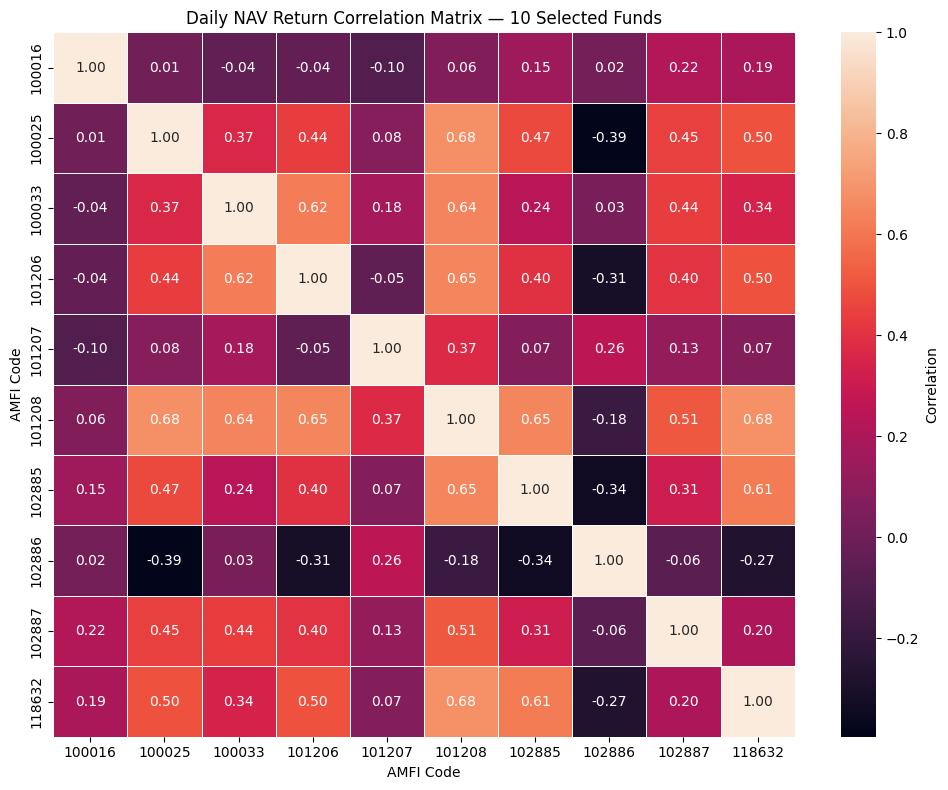

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title('Daily NAV Return Correlation Matrix — 10 Selected Funds')
plt.xlabel('AMFI Code')
plt.ylabel('AMFI Code')

plt.tight_layout()
plt.show()

#Sector Allocation Donut Chart

In [ ]:
print(fund_holdings.columns)
print("\nShape:", fund_holdings.shape)
fund_holdings.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

Shape: (322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
# Aggregate portfolio weights by sector
sector_allocation = (
    fund_holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(sector_allocation)

            sector  weight_pct
0          Banking      652.26
1               IT      455.47
2           Pharma      407.45
3       Automobile      323.65
4        Utilities      265.54
5             FMCG      229.11
6   Infrastructure      192.16
7      Diversified      169.23
8          Telecom      145.62
9   Consumer Goods      127.61
10            NBFC      119.09
11          Energy      117.91
12          Cement      105.03
13          Paints       89.86


In [ ]:
fig = px.pie(
    sector_allocation,
    values='weight_pct',
    names='sector',
    title='Sector Allocation Across Mutual Fund Equity Holdings',
    hole=0.4
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    height=650
)

fig.show()

<!doctype html>

#Transaction Type Distribution

In [ ]:
transaction_counts = transactions['transaction_type'].value_counts()

print(transaction_counts)

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


In [ ]:
import plotly.express as px

fig = px.pie(
    transaction_counts,
    values=transaction_counts.values,
    names=transaction_counts.index,
    title='Distribution of Mutual Fund Transaction Types',
    hole=0.4
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    height=550
)

fig.show()

<!doctype html>

#Monthly Active SIP Accounts Trend

In [ ]:
print(sip_inflows[['month', 'active_sip_accounts_crore']].head())

       month  active_sip_accounts_crore
0 2022-01-01                       4.91
1 2022-02-01                       4.93
2 2022-03-01                       5.09
3 2022-04-01                       5.48
4 2022-05-01                       5.55


In [ ]:
import plotly.express as px

fig = px.line(
    sip_inflows,
    x='month',
    y='active_sip_accounts_crore',
    title='Growth in Active SIP Accounts (2022–2025)',
    labels={
        'month': 'Month',
        'active_sip_accounts_crore': 'Active SIP Accounts (Crore)'
    },
    markers=True
)

fig.update_layout(
    height=550,
    hovermode='x unified'
)

fig.show()

<!doctype html>

#Top 10 States by SIP Investment

In [ ]:
print(state_sip.head())

            state  amount_inr
0  Madhya Pradesh    20682243
1          Punjab    20140064
2       Telangana    18620216
3      Tamil Nadu    18404368
4         Gujarat    18378904


In [ ]:
# Get Top 10 States by SIP Investment
top10_states = state_sip.nlargest(10, 'amount_inr')

import plotly.express as px

fig = px.bar(
    top10_states,
    x='amount_inr',
    y='state',
    orientation='h',
    title='Top 10 States by SIP Investment Amount',
    labels={
        'amount_inr': 'Total SIP Investment (₹)',
        'state': 'State'
    },
    text='amount_inr'
)

fig.update_layout(
    height=600,
    yaxis={'categoryorder': 'total ascending'}
)

fig.update_traces(
    texttemplate='₹%{text:.2s}',
    textposition='outside'
)

fig.show()

<!doctype html>

#Key EDA Findings

1. **NAV trends across the 40 mutual fund schemes showed noticeable variation between 2022 and 2026, indicating differences in fund performance and investment strategies.**  
   *Supporting Chart: NAV Trend Analysis*

2. **SBI Mutual Fund demonstrated the strongest AUM growth among the analysed fund houses, reaching ₹12.5 lakh crore in 2025.**  
   *Supporting Chart: AUM Growth Analysis*

3. **Monthly SIP inflows showed an overall upward trend from 2022 to 2025 and reached an all-time high of ₹31,002 crore in December 2025.**  
   *Supporting Chart: SIP Inflow Trend Analysis*

4. **Category-level inflows varied significantly across months, with equity-oriented categories such as Flexi Cap and Large & Mid Cap attracting comparatively strong investor inflows during several periods.**  
   *Supporting Chart: Category Inflow Heatmap*

5. **The investor base was distributed across multiple age groups, demonstrating participation from both younger and older investors in mutual fund investments.**  
   *Supporting Chart: Investor Age Group Distribution*

6. **SIP investment amounts varied across age groups, indicating differences in investment capacity and contribution patterns among investors.**  
   *Supporting Chart: SIP Amount Distribution by Age Group*

7. **Mutual fund investments showed participation from different gender groups, highlighting a diverse investor demographic.**  
   *Supporting Chart: Investor Gender Distribution*

8. **SIP investment amounts differed across states, indicating geographical variation in mutual fund participation and investment activity.**  
   *Supporting Chart: Total SIP Amount by State*

9. **The total mutual fund folio count almost doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting substantial growth in investor participation.**  
   *Supporting Chart: Folio Count Growth Analysis*

10. **The correlation analysis of daily NAV returns showed varying relationships among the selected funds, with some funds displaying strong positive correlations while others had weak or negative correlations.**  
    *Supporting Chart: NAV Return Correlation Matrix*

11. **Banking represented the largest aggregated sector allocation across the analysed mutual fund equity holdings, followed by sectors such as IT and Pharma.**  
    *Supporting Chart: Sector Allocation Donut Chart*